# BoC Rate Decisions — 3-Way Direction Prediction Experiment

This notebook runs the full predictor lineup on the discrete BoC task:
**a probability distribution over {cut, hold, hike} at the next fixed
announcement date, issued four weeks (28 days) before the announcement**,
scored with the **Ranked Probability Score (RPS)**. Read
`01_boc_data_exploration.ipynb` first for the problem framing, data layer,
and cutoff-discipline walkthrough. A compact **binary warm-up** (*cut vs no
cut*, Brier-scored) opens the experiment as a copy-paste reference for
naturally binary problems — prediction-market-style questions — before the
3-way main event.

**Why a 28-day lead.** On the eve of a decision, the 2-year GoC yield has
already absorbed the market consensus and the outcome is priced to
near-certainty — a T−1 "forecast" mostly reads market expectations off a
curve. Four weeks out, the decision is genuinely uncertain, so the skill
being measured is *anticipation*. The eve-of-decision variant is kept as a
diagnostic, and a dedicated section compares the two leads directly.

**The leakage problem, discrete edition.** Frontier LLMs were trained on
data that includes news coverage of every historical BoC decision. For
backtest origins in 2010–2024, an LLM-based predictor may simply *remember*
what the Bank decided — and unlike the continuous use cases, here
memorisation is worth even more, because a single recalled label (cut /
hold / hike) is the entire answer. Backtest RPS for LLMP and the agent is
therefore an **upper bound on live skill**, useful for verifying the
pipeline and calibration format, not for claiming forecasting ability. The
conventional predictors (climatology, multinomial logistic) are blind to
the future by construction, so their backtest scores are honest.

The protected 2025–2026 eval window at the end is closer to (and partly
beyond) current model training cutoffs — that comparison is fairer, and the
budget-gated `evaluate()` harness keeps it honest.

**What's here:**

1. Setup and experiment config — smoke (3 origins) vs full (120 origins).
2. Spec — loaded from YAML; ordered `categories` + explicit `origin_dates`.
3. Binary warm-up — the compact Brier-scored reference, and the
   RPS(K=2) ≡ Brier identity.
4. Predictors — climatology, multinomial logistic, categorical LLMP,
   agentic analyst.
5. Backtest — cached on disk; RPS leaderboard with skill scores.
6. Skill vs lead time — the canonical T−28 forecast against the T−1
   eve-of-decision diagnostic.
7. Decision timeline and one-vs-rest reliability curves.
8. Inspecting agent reasoning — the seam for reasoning-alignment evaluation.
9. Protected eval — budget-gated 2025–2026 window.

---
## 1. Setup

The analytical code lives in modules alongside this notebook:

- `data.py` — registers the target rate, derived decision series, and covariates.
- `predictors/` — the (multinomial) logistic baseline and the BoC LLMP recipes.
- `analyst_agent/` — the agentic BoC analyst (prompt builder + configs).
- `analysis.py` / `plots.py` — score leaderboard, calibration, timeline.

Specs (all under `implementations/boc_rate_decisions/specs/`):

| Spec file | Lead | Origins | Window | Notes |
|---|---|---|---|---|
| `boc_rate_direction_smoke.yaml` | T−28 | 3 | 2024 | One hold + two cuts; fast dev loop |
| `boc_rate_direction_backtest.yaml` | T−28 | 120 | 2010–2024 | **Canonical**: three easing + three tightening cycles |
| `boc_rate_direction_eval.yaml` | T−28 | 12 | 2025–Jun 2026 | Protected, `max_runs: 5` |
| `boc_rate_direction_eve_smoke.yaml` / `_eve_backtest.yaml` | T−1 | 3 / 120 | same windows | Eve-of-decision diagnostic for the lead comparison |
| `boc_rate_cut_smoke.yaml` / `boc_rate_cut_backtest.yaml` | T−1 | 3 / 120 | same windows | The binary reference task used in the warm-up |

A use-case test (`test_specs.py`) asserts every origin list stays consistent
with `meeting_schedule.yaml` at each spec's own lead.

Populate the data cache once before running:

```bash
uv run python scripts/fetch_boc.py
```

In [1]:
from __future__ import annotations

import warnings
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import yaml
from dotenv import load_dotenv


warnings.filterwarnings("ignore")

ROOT = Path.cwd().resolve().parents[1]
load_dotenv(ROOT / ".env")

from aieng.forecasting.evaluation import BacktestSpec, cached_backtest, describe_spec
from boc_rate_decisions.analysis import one_vs_rest_frame, predictions_to_frame, rationales_table, score_leaderboard
from boc_rate_decisions.data import DIRECTION_SERIES_ID, RATE_CUT_EVENT_SERIES_ID, build_boc_service
from boc_rate_decisions.plots import plot_decision_timeline, plot_reliability_curve


STATCAN_CACHE = ROOT / "data" / "statcan"
FRED_CACHE = ROOT / "data" / "fred"
PREDICTIONS_DIR = ROOT / "data" / "predictions"
SPECS_DIR = ROOT / "implementations" / "boc_rate_decisions" / "specs"

svc = build_boc_service(statcan_cache_dir=STATCAN_CACHE, fred_cache_dir=FRED_CACHE)

_as_of = datetime.now(tz=timezone.utc).replace(tzinfo=None)
direction_df = svc.get_series(DIRECTION_SERIES_ID, as_of=_as_of)
event_df = svc.get_series(RATE_CUT_EVENT_SERIES_ID, as_of=_as_of)
n_cuts = int((direction_df["value"] == -1.0).sum())
n_holds = int((direction_df["value"] == 0.0).sum())
n_hikes = int((direction_df["value"] == 1.0).sum())
print(f"Direction series: {len(direction_df)} resolved meetings — {n_cuts} cuts, {n_holds} holds, {n_hikes} hikes")

Direction series: 139 resolved meetings — 15 cuts, 106 holds, 18 hikes


In [2]:
# ── Experiment configuration ──────────────────────────────────────────────────
# Set EXPERIMENT_CONFIG to control which backtest runs throughout this notebook.
#
#   "smoke"  3 origins in 2024 (one hold, two cuts)
#            fast smoke test: ~3 LLM calls per LLM-based predictor
#   "full"   120 origins, 2010-2024
#            the canonical backtest; first LLM-based run makes 120 calls
#            per predictor before caching

EXPERIMENT_CONFIG = "smoke"

_BACKTEST_SPEC_FILES = {
    "smoke": "boc_rate_direction_smoke.yaml",
    "full": "boc_rate_direction_backtest.yaml",
}
_BACKTEST_SPEC_FILE = _BACKTEST_SPEC_FILES[EXPERIMENT_CONFIG]
# Cache key for artefacts under data/predictions/<spec_id>/<predictor_id>.yaml
BACKTEST_SPEC_ID = f"boc_rate_direction_{EXPERIMENT_CONFIG}"
# The binary warm-up uses the matching binary reference spec.
_WARMUP_SPEC_FILES = {
    "smoke": "boc_rate_cut_smoke.yaml",
    "full": "boc_rate_cut_backtest.yaml",
}
_WARMUP_SPEC_FILE = _WARMUP_SPEC_FILES[EXPERIMENT_CONFIG]
WARMUP_SPEC_ID = f"boc_rate_cut_{EXPERIMENT_CONFIG}"

# The lead-time comparison uses the eve-of-decision (T-1) diagnostic spec.
_EVE_SPEC_FILES = {
    "smoke": "boc_rate_direction_eve_smoke.yaml",
    "full": "boc_rate_direction_eve_backtest.yaml",
}
_EVE_SPEC_FILE = _EVE_SPEC_FILES[EXPERIMENT_CONFIG]
EVE_SPEC_ID = f"boc_rate_direction_eve_{EXPERIMENT_CONFIG}"

print(f"Config: {EXPERIMENT_CONFIG!r}  →  {_BACKTEST_SPEC_FILE}")
print(f"  warm-up: {_WARMUP_SPEC_FILE}   eve diagnostic: {_EVE_SPEC_FILE}")

Config: 'smoke'  →  boc_rate_direction_smoke.yaml
  warm-up: boc_rate_cut_smoke.yaml   eve diagnostic: boc_rate_direction_eve_smoke.yaml


---
## 2. The backtest spec

Three things distinguish this spec from the continuous use cases:

- **`payload_type: categorical`** on the task — predictors must return a
  `CategoricalForecast(probabilities={...})` and the harness scores with
  RPS instead of CRPS.
- **`categories`** — the task declares the *ordered* outcome set and the
  mapping to series values: `cut(−1) < hold(0) < hike(+1)`. The order is
  what makes RPS distance-sensitive: mass on `hike` when the Bank cuts is
  penalised through *two* cumulative thresholds, mass on `hold` through one.
- **`origin_dates`** — BoC meetings are an irregular calendar (eight per
  year, unevenly spaced), so the spec lists every forecast origin explicitly
  (`announcement_date − 28 days`) instead of deriving origins from a stride.
  Scheduled meetings are never closer than 35 days apart, so the previous
  decision is always visible at the origin.

In [3]:
with (SPECS_DIR / _BACKTEST_SPEC_FILE).open() as f:
    backtest_spec = BacktestSpec.model_validate(yaml.safe_load(f))

print(describe_spec(backtest_spec, data_service=svc))

BacktestSpec
  description: Three-origin smoke backtest for local and CI testing of the BoC rate-direction pipeline. Same task and warmup as boc_rate_direction_backtest, restricted to one hold and two cut meetings in 2024, with origins 28 days before each announcement.
  start:       2024-03-01 00:00:00
  end:         2024-09-30 00:00:00
  stride:      1
  warmup:      8
  origins:     3 explicit dates (irregular calendar)

Task: boc_rate_direction_next_meeting
  description: At the Bank of Canada fixed announcement date occurring 28 days after the forecast origin, will the Bank CUT, HOLD, or HIKE its target for the overnight rate? Outcome is the direction of the target-rate change at that announcement (any size). Announcements are at 09:45 ET; the forecast must be issued with information available four weeks before the announcement, before markets have converged on the decision.
  horizons:    28
  frequency:   D
  payload:     categorical
  categories:  cut(-1) < hold(0) < hike(1)
  

---
## 3. Warm-up: the binary special case (a copy-paste reference)

Many real prediction problems are naturally binary — *will X happen by
date D?* — and prediction markets trade exactly that contract. Before the
3-way main event, this section runs the same machinery on the binary view
of the problem (*cut vs no cut*, `payload_type: binary`, Brier-scored) so
you have a minimal, complete reference to copy for your own binary tasks:

- the task: `specs/boc_rate_cut_smoke.yaml` / `boc_rate_cut_backtest.yaml`,
- the floor baseline: `HistoricalFrequencyPredictor` (the constant base rate),
- the LLMP recipe: `build_llmp_binary` wrapping
  `BinaryProbabilityLLMPredictor`,
- the conventional model: the same `BoCLogisticPredictor`, which dispatches
  to plain logistic regression on binary tasks.

The binary reference stays at the **T−1 (eve-of-decision) lead**: its job is
to demonstrate the payload and scoring format in the fewest moving parts,
not the lead-time question — that analysis belongs to the 3-way experiment
below.

**Why the two framings agree.** The unnormalized RPS over \(K\) ordered
categories is a sum of \(K-1\) cumulative binary Brier scores, so for
\(K = 2\) it *is* the Brier score \((p - y)^2\). (Brier's original 1950
multi-category score is twice this — both conventions appear in the
literature; this codebase uses the cumulative form everywhere.) The cell
below verifies the identity numerically with `compute_rps` and
`compute_brier_score` — the binary problem is the \(K{=}2\) corner of the
categorical machinery, which is exactly why the 3-way framing is the more
general reference.

In [4]:
from aieng.forecasting.evaluation import compute_brier_score, compute_rps
from aieng.forecasting.methods import HistoricalFrequencyPredictor
from boc_rate_decisions.predictors import BoCLogisticPredictor, build_llmp_binary


# RPS(K=2) == Brier identity: categories ordered [no-cut, cut].
for p_cut, outcome in [(0.1, 0), (0.3, 1), (0.85, 1)]:
    rps = compute_rps([[1.0 - p_cut, p_cut]], [outcome])
    brier = compute_brier_score([p_cut], [float(outcome)])
    print(f"P(cut)={p_cut:.2f}, outcome={outcome}:  RPS(K=2) = {rps:.4f}  ==  Brier = {brier:.4f}")

# The compact binary experiment: floor baseline + logistic + LLMP, Brier-scored.
with (SPECS_DIR / _WARMUP_SPEC_FILE).open() as f:
    warmup_spec = BacktestSpec.model_validate(yaml.safe_load(f))

warmup_predictors = [HistoricalFrequencyPredictor(), BoCLogisticPredictor(), build_llmp_binary()]
warmup_results = {}
for predictor in warmup_predictors:
    warmup_results[predictor.predictor_id] = cached_backtest(
        predictor=predictor, spec=warmup_spec, spec_id=WARMUP_SPEC_ID, data_service=svc, store_dir=PREDICTIONS_DIR
    )

print()
print(score_leaderboard(warmup_results, reference_id="historical_frequency").to_string(index=False))

P(cut)=0.10, outcome=0:  RPS(K=2) = 0.0100  ==  Brier = 0.0100
P(cut)=0.30, outcome=1:  RPS(K=2) = 0.4900  ==  Brier = 0.4900
P(cut)=0.85, outcome=1:  RPS(K=2) = 0.0225  ==  Brier = 0.0225



                                                   predictor_id metric  mean_score  n_predictions  n_skipped_origins  skill_vs_reference
llmp_binary_probability_boc_cut_v1_rlow[gemini-3-flash-preview]  brier    0.018667              3                  0              0.9686
                                             boc_logistic_macro  brier    0.303607              3                  0              0.4893
                                           historical_frequency  brier    0.594444              3                  0              0.0000


---
## 4. Predictors

Four predictors spanning the methodology spectrum, all implementing the same
`Predictor` API:

| Group | Predictor | What it sees | Notes |
|---|---|---|---|
| Floor baseline | `CategoricalFrequencyPredictor` | Past outcomes only | Constant climatological distribution; the bar every other predictor must clear |
| Conventional | `BoCLogisticPredictor` | Leak-safe macro features | Multinomial logistic regression fit at every origin: yield spread, rate momentum, inflation gap, unemployment momentum |
| LLMP | `CategoricalProbabilityLLMPredictor` | Outcome history + prompt context | Direct distribution elicitation in one structured call; no tools, no covariates |
| Agentic | `AgentPredictor` (BoC analyst) | Rate path + outcome history + **the same macro features as the logistic model** | Reasons over the evidence; emits a cut/hold/hike distribution + rationale + key signals |

The agent and the logistic model deliberately receive **identical macro
indicators** (the agent's prompt builder imports the same feature function),
making this a clean comparison of *conventional fitting* vs *LLM reasoning*
over the same information set. The LLMP variant sees less — just the
labelled outcome sequence (`2024-04-10: hold`, …) and a description — which
isolates the value of the covariates.

In [5]:
from aieng.forecasting.methods import CategoricalFrequencyPredictor
from boc_rate_decisions.analyst_agent import build_boc_agent_predictor, build_boc_basic_config
from boc_rate_decisions.predictors import build_llmp_direction


climatology = CategoricalFrequencyPredictor()
logistic = BoCLogisticPredictor()  # dispatches to multinomial on categorical tasks
llmp = build_llmp_direction(model="gemini-3-flash-preview", reasoning_effort="low")
agent = build_boc_agent_predictor(build_boc_basic_config(model="gemini-3-flash-preview"))

# News-grounded agent variant (web search with temporal cutoffs). Leakage
# risk is higher on historical dates; enable deliberately, not by default.
# from boc_rate_decisions.analyst_agent import build_boc_news_config
# agent_news = build_boc_agent_predictor(build_boc_news_config(model="gemini-3-flash-preview"))

all_predictors = [climatology, logistic, llmp, agent]

PREDICTOR_COLORS: dict[str, str] = {
    climatology.predictor_id: "#7f7f7f",
    logistic.predictor_id: "#1f77b4",
    llmp.predictor_id: "#d62728",
    agent.predictor_id: "#ff7f0e",
}
PREDICTOR_LABELS: dict[str, str] = {
    climatology.predictor_id: "Climatology",
    logistic.predictor_id: "Multinomial logistic",
    llmp.predictor_id: "LLMP direction",
    agent.predictor_id: "Agent (basic)",
}

for p in all_predictors:
    print(f"  {p.predictor_id}")

  categorical_frequency
  boc_logistic_macro
  llmp_categorical_probability_boc_direction_v1_rlow[gemini-3-flash-preview]
  agent_predictor_boc_analyst_basic_categorical


---
## 5. Backtest (cached on disk)

`cached_backtest` writes each `BacktestResult` to
`data/predictions/<spec_id>/<predictor_id>.yaml` and reuses it on subsequent
runs; pass `force_refresh=True` to recompute. The climatology and logistic
predictors are free; the LLMP and agent make one LLM call per origin on a
first run (3 calls under `smoke`, 120 under `full`).

**Reading the scores.** RPS accumulates squared error over the cumulative
distribution. A confident, correct forecast scores near 0; a confident
forecast on the *adjacent* category costs ~1; a confident forecast on the
*opposite tail* (hike when the Bank cuts) costs ~2 — the ordering is what
separates RPS from a plain multi-class Brier. Mean RPS over the window
rewards predictors that keep mass on hold through the long quiet stretches
*and* shift it toward the right tail in time for cycle turns — four weeks
before each announcement, while the outcome is still genuinely open.
Remember the asymmetry from the intro — only the climatology and logistic
rows of the leaderboard are leakage-free.

In [6]:
from aieng.forecasting.evaluation.backtest import BacktestResult


results: dict[str, BacktestResult] = {}

for predictor in all_predictors:
    print(f"Running {predictor.predictor_id} ...", flush=True)
    results[predictor.predictor_id] = cached_backtest(
        predictor=predictor,
        spec=backtest_spec,
        spec_id=BACKTEST_SPEC_ID,
        data_service=svc,
        store_dir=PREDICTIONS_DIR,
    )
    r = results[predictor.predictor_id]
    print(f"  mean RPS = {r.mean_score:.4f}  ({len(r.predictions)} predictions, {r.skipped_origins} skipped)")

Running categorical_frequency ...


  mean RPS = 0.6158  (3 predictions, 0 skipped)
Running boc_logistic_macro ...


  mean RPS = 0.3680  (3 predictions, 0 skipped)
Running llmp_categorical_probability_boc_direction_v1_rlow[gemini-3-flash-preview] ...


  mean RPS = 0.1151  (3 predictions, 0 skipped)
Running agent_predictor_boc_analyst_basic_categorical ...


  mean RPS = 0.1150  (3 predictions, 0 skipped)


---
## 6. RPS leaderboard

`skill_vs_reference` is the skill score against the
`CategoricalFrequencyPredictor`: positive = beats the climatology, 0 =
matches it, negative = worse than knowing nothing. With holds at ~76%, the
climatological forecast is a deceptively low bar that conditions-blind
models struggle to clear — most of the score separation happens at the
handful of cycle-turn meetings.

In [7]:
board = score_leaderboard(results, reference_id=climatology.predictor_id)
board["label"] = board["predictor_id"].map(PREDICTOR_LABELS)
print(board.set_index("label").drop(columns="predictor_id").to_string())

predictions_df = predictions_to_frame(results, direction_df)
print(f"\nTidy prediction rows: {len(predictions_df)}")
print(predictions_df[["predictor_id", "meeting_date", "p_cut", "p_hold", "p_hike", "outcome_label", "score"]].head())

                     metric  mean_score  n_predictions  n_skipped_origins  skill_vs_reference
label                                                                                        
Agent (basic)           rps    0.115033              3                  0              0.8132
LLMP direction          rps    0.115067              3                  0              0.8131
Multinomial logistic    rps    0.368007              3                  0              0.4023
Climatology             rps    0.615751              3                  0              0.0000

Tidy prediction rows: 12
            predictor_id meeting_date     p_cut    p_hold    p_hike  \
0  categorical_frequency   2024-04-10  0.049180  0.803279  0.147541   
1  categorical_frequency   2024-06-05  0.048780  0.804878  0.146341   
2  categorical_frequency   2024-09-04  0.064000  0.792000  0.144000   
3     boc_logistic_macro   2024-04-10  0.042058  0.947731  0.010212   
4     boc_logistic_macro   2024-06-05  0.035136  0.9539

---
## 7. Skill vs lead time: T−28 vs the eve of the decision

The same meetings, the same predictors, two information states: the
canonical four-week lead and the eve-of-decision (T−1) diagnostic
(`boc_rate_direction_eve_*.yaml`). Three things to expect:

- **Climatology is lead-invariant** — it conditions on nothing, so its RPS
  is identical at both leads. It anchors the comparison.
- **Conditioning predictors should improve toward T−1** as the market
  converges: the yield spread is far more decisive the day before a
  decision than four weeks out. The *gap* between a predictor's T−28 and
  T−1 scores is roughly "how much of its skill is anticipation vs reading
  the market's final answer".
- **For the LLM-based rows, interpret with the leakage caveat** — on
  historical origins a memorised outcome inflates both leads equally, which
  itself is diagnostic: a genuine forecaster should get *worse* as the lead
  grows; a memoriser won't.

In [8]:
with (SPECS_DIR / _EVE_SPEC_FILE).open() as f:
    eve_spec = BacktestSpec.model_validate(yaml.safe_load(f))

eve_results: dict[str, BacktestResult] = {}
for predictor in all_predictors:
    eve_results[predictor.predictor_id] = cached_backtest(
        predictor=predictor,
        spec=eve_spec,
        spec_id=EVE_SPEC_ID,
        data_service=svc,
        store_dir=PREDICTIONS_DIR,
    )

lead_comparison = score_leaderboard(results)[["predictor_id", "mean_score"]].rename(columns={"mean_score": "rps_t28"})
eve_board = score_leaderboard(eve_results)[["predictor_id", "mean_score"]].rename(columns={"mean_score": "rps_t1"})
lead_comparison = lead_comparison.merge(eve_board, on="predictor_id")
lead_comparison["anticipation_gap"] = (lead_comparison["rps_t28"] - lead_comparison["rps_t1"]).round(4)
lead_comparison["label"] = lead_comparison["predictor_id"].map(PREDICTOR_LABELS)
print(lead_comparison.set_index("label").drop(columns="predictor_id").to_string())
print()
print("anticipation_gap = RPS(T-28) - RPS(T-1): how much score the predictor")
print("recovers as the market converges. ~0 for climatology by construction.")

                       rps_t28    rps_t1  anticipation_gap
label                                                     
Agent (basic)         0.115033  0.015767            0.0993
LLMP direction        0.115067  0.024434            0.0906
Multinomial logistic  0.368007  0.306900            0.0611
Climatology           0.615751  0.615751            0.0000

anticipation_gap = RPS(T-28) - RPS(T-1): how much score the predictor
recovers as the market converges. ~0 for climatology by construction.


---
## 8. Decision timeline

Predicted P(cut) (solid) and P(hike) (dashed) at every meeting, with
realised cuts shaded red and realised hikes shaded teal. This is the
qualitative complement to the leaderboard: a good predictor's solid line
rises *into* the red bands, its dashed line into the teal ones, and both
stay near zero through the long holds. Watch for two characteristic failure
modes:

- **Flat-lining** — never deviating from the climatology (no conditioning).
- **Chasing** — probability spikes only *after* the first move of a cycle
  has already happened (reacting, not anticipating).

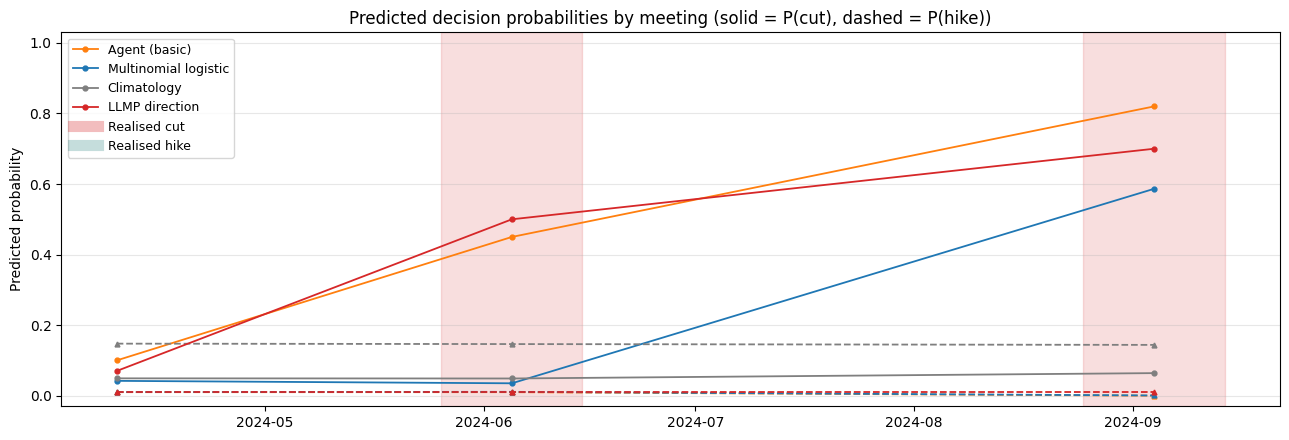

In [9]:
fig, _ = plot_decision_timeline(predictions_df, colors=PREDICTOR_COLORS, labels=PREDICTOR_LABELS)
plt.show()

---
## 9. Calibration (one-vs-rest reliability curves)

Proper scores decompose into calibration + refinement, and for decision
support calibration is the part that matters: when the predictor says 30%
cut, does a cut happen about 30% of the time? For a categorical task, each
category is checked **one-vs-rest**: `one_vs_rest_frame(df, "cut")` turns
the tidy frame into a binary-style frame (`probability = p_cut`,
`outcome = 1` iff the realised decision was a cut) that the same reliability
machinery consumes. Points above the diagonal mean the predictor
under-predicts that outcome in that bin; below means over-prediction.

With only ~120 meetings the bins are thin (marker size shows the count), so
read this as a coarse diagnostic, not a precise measurement. This section is
only meaningful under the `full` config — three smoke origins cannot
populate a reliability curve.

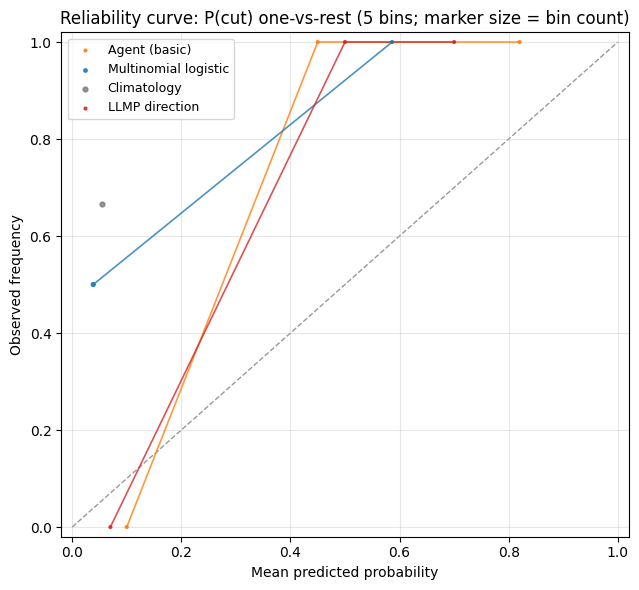

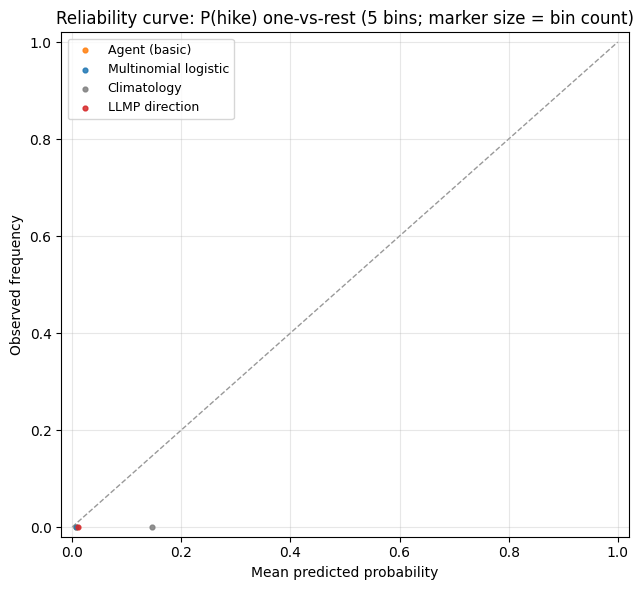

In [10]:
for category in ["cut", "hike"]:
    ovr = one_vs_rest_frame(predictions_df, category)
    fig, _ = plot_reliability_curve(
        ovr, n_bins=5, colors=PREDICTOR_COLORS, labels=PREDICTOR_LABELS, title_suffix=f"P({category}) one-vs-rest"
    )
    plt.show()

---
## 10. Inspecting agent reasoning

The agent's `CategoricalAgentForecastOutput` carries a `reasoning` trace and
`key_signals` alongside the cut/hold/hike distribution, preserved in each
prediction's metadata. Two reasons to look at them:

1. **Debugging now** — a probability is a single number; the rationale tells
   you *why* the agent moved (or failed to move) off the base rate.
2. **Reasoning alignment later** — the Bank publishes its own rationale with
   every decision. The planned LLM evaluator will compare the agent's
   pre-decision reasoning against the Bank's published explanation, scoring
   whether the agent was right *for the right reasons*. These metadata
   fields are that evaluator's input.

In [11]:
rationales = rationales_table(results[agent.predictor_id])

for _, row in rationales.iterrows():
    outcome_row = predictions_df[
        (predictions_df["predictor_id"] == agent.predictor_id) & (predictions_df["meeting_date"] == row["meeting_date"])
    ]
    realised = outcome_row["outcome_label"].iloc[0] if not outcome_row.empty else "unresolved"
    dist = f"cut {row['p_cut']:.2f} / hold {row['p_hold']:.2f} / hike {row['p_hike']:.2f}"
    print(f"Meeting {row['meeting_date'].date()}  —  {dist}  (realised: {realised})")
    if row.get("meta_key_signals") is not None:
        print(f"  signals: {row['meta_key_signals']}")
    if row.get("meta_agent_rationale") is not None:
        print(f"  reasoning: {str(row['meta_agent_rationale'])[:500]}")
    print()

Meeting 2024-04-10  —  cut 0.10 / hold 0.89 / hike 0.01  (realised: hold)
  signals: ["March 6 BoC statement indicating it is 'too early' to lower rates", 'Deeply negative yield spread (-0.89) signaling market expectations of future cuts', 'Inflation gap (+0.86) remains above target but is narrowing', 'Rising unemployment momentum (+0.7) indicating labor market slack is forming']
  reasoning: As of mid-March 2024, the Bank of Canada is in a 'wait-and-see' posture, having held the policy rate at 5.0% since July 2023. The most recent policy announcement (March 6, 2024) explicitly stated that it was 'too early' to consider a rate cut, as core inflation measures remained elevated and persistent. While the 2-year GoC yield is trading significantly below the policy rate (spread of -0.89), signaling market expectations for easing later in the year, the Bank's institutional gradualism and re

Meeting 2024-06-05  —  cut 0.45 / hold 0.54 / hike 0.01  (realised: cut)
  signals: ['Negative yield s

---
## 11. Protected eval (budget-gated)

`specs/boc_rate_direction_eval.yaml` covers the 12 announcements from
January 2025 through June 2026 at the canonical 28-day lead: the tail of
the easing cycle (cuts in Jan, Mar, Sep, Oct 2025) followed by an extended
hold at 2.25%. The window contains no hikes — it cannot reward hike
discrimination, but RPS still scores how much mass predictors waste on the
hike tail. This window is closer to — and partly beyond — current model
training cutoffs, making it the fairest available comparison for the
LLM-based predictors.

`max_runs: 5` is enforced through the `EvalTracker` (state in
`data/eval_runs.yaml`, gitignored). The scarcity is the point: an eval you
can re-run freely becomes another backtest to over-fit. Flip `RUN_PROTECTED_EVAL`
to `True` only when you have a predictor configuration you're confident in.

In [12]:
from aieng.forecasting.evaluation import EvalSpec, EvalTracker, evaluate


RUN_PROTECTED_EVAL = False  # each run spends budget; max_runs: 5 per tracker

if RUN_PROTECTED_EVAL:
    with (SPECS_DIR / "boc_rate_direction_eval.yaml").open() as f:
        eval_spec = EvalSpec.model_validate(yaml.safe_load(f))

    tracker = EvalTracker(ROOT / "data" / "eval_runs.yaml")
    print(f"Runs already spent: {tracker.runs_for(eval_spec.spec_id)}/{eval_spec.max_runs}\n")

    eval_results = {}
    for predictor in all_predictors:
        eval_results[predictor.predictor_id] = evaluate(
            predictor=predictor, spec=eval_spec, data_service=svc, tracker=tracker
        )
        r = eval_results[predictor.predictor_id]
        print(
            f"  {PREDICTOR_LABELS[predictor.predictor_id]:20s} mean RPS = {r.mean_score:.4f}  (run {r.run_number}/{eval_spec.max_runs})"
        )

    eval_board = score_leaderboard(eval_results, reference_id=climatology.predictor_id)
    print()
    print(eval_board.to_string(index=False))
else:
    print("RUN_PROTECTED_EVAL = False — flip to True to spend an eval run.")

RUN_PROTECTED_EVAL = False — flip to True to spend an eval run.


---
## 12. What's next — the deferred components

This notebook completes the **quantitative** version of the problem. Three
components are deliberately deferred, and the code leaves explicit seams for
each:

1. **BoC communications as context.** Every decision comes with a press
   release, and four per year come with a full Monetary Policy Report. The
   `CategoricalProbabilityLLMPredictorConfig.user_prompt_suffix` hook and the
   `build_boc_news_config` retrieval sub-agent are the insertion points for
   report-grounded variants once the document ingestion work (Track 2)
   lands. The key engineering constraint carries over unchanged: documents
   must be filtered by `released_at`, exactly like series data.

2. **Reasoning-alignment evaluation.** The agent already emits `reasoning`
   and `key_signals` per meeting (section 10). An LLM evaluator comparing
   that rationale against the Bank's own published explanation would
   complement the RPS with a *process* metric — was the predictor right for
   the right reasons? This matters most precisely where the score is least
   trustworthy (historical origins with leakage).

3. **Live forecasting.** The cleanest evaluation needs no leakage analysis
   at all: forecast the *next* announcement before it happens. The eval spec
   ends at June 2026; extending `meeting_schedule.yaml` with the Bank's
   published 2027 calendar and issuing forecasts the day before each
   announcement turns this use case into a standing live experiment — eight
   genuinely out-of-sample data points per year.